# Problem Statement
**The objective of this project is to predict customer churn using machine learning techniques. 
By analyzing customer demographics, services, and billing information, the model identifies customers who are likely to leave the telecom service.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [2]:
df = pd.read_csv('Customer-Churn.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# EDA Process

In [4]:
df.shape

(7043, 21)

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
# Cheaking missing values
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Cheaking balancing in target column.
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Here **0** have more than **1**, means Imbalance

# Visualization

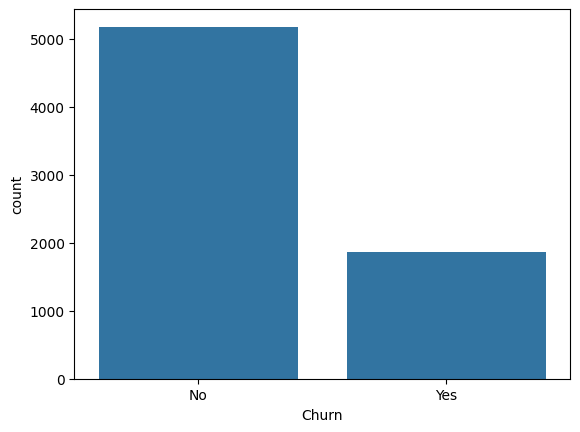

In [9]:
sns.countplot(x="Churn",data=df)
plt.show()

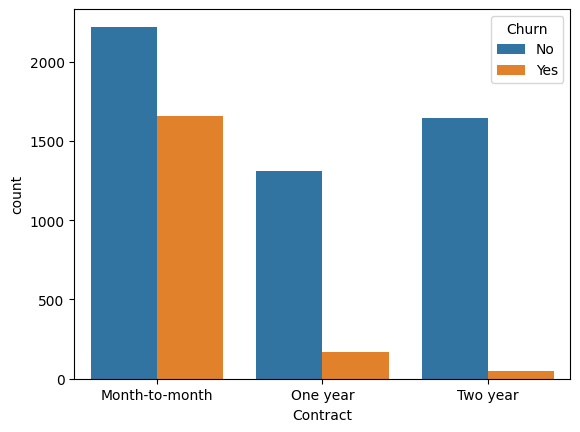

In [10]:
# Contract vs Churn
sns.countplot(x="Contract",hue="Churn",data=df)
plt.show()

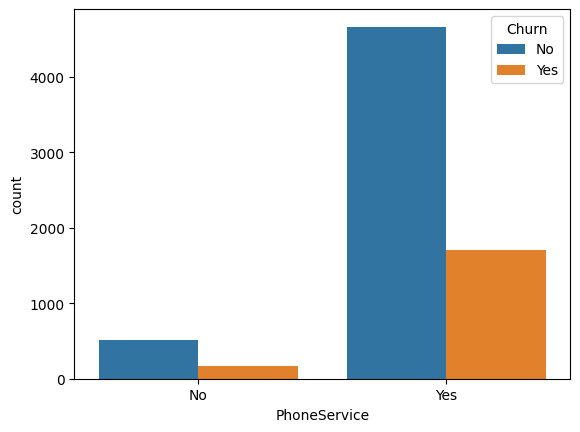

In [11]:
# PhoneService vs Churn
sns.countplot(x="PhoneService",hue="Churn",data=df)
plt.show()

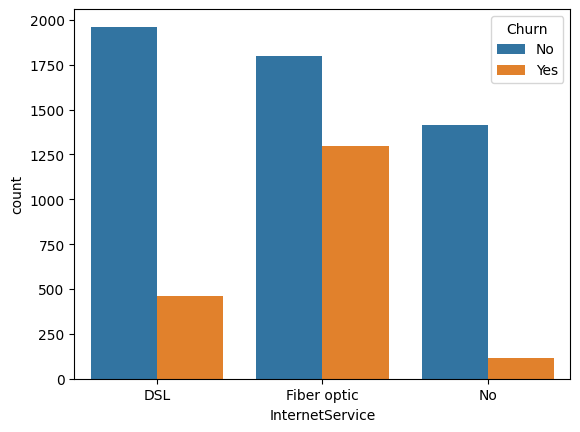

In [12]:
# InternetService vs Churn
sns.countplot(x="InternetService",hue="Churn",data=df)
plt.show()

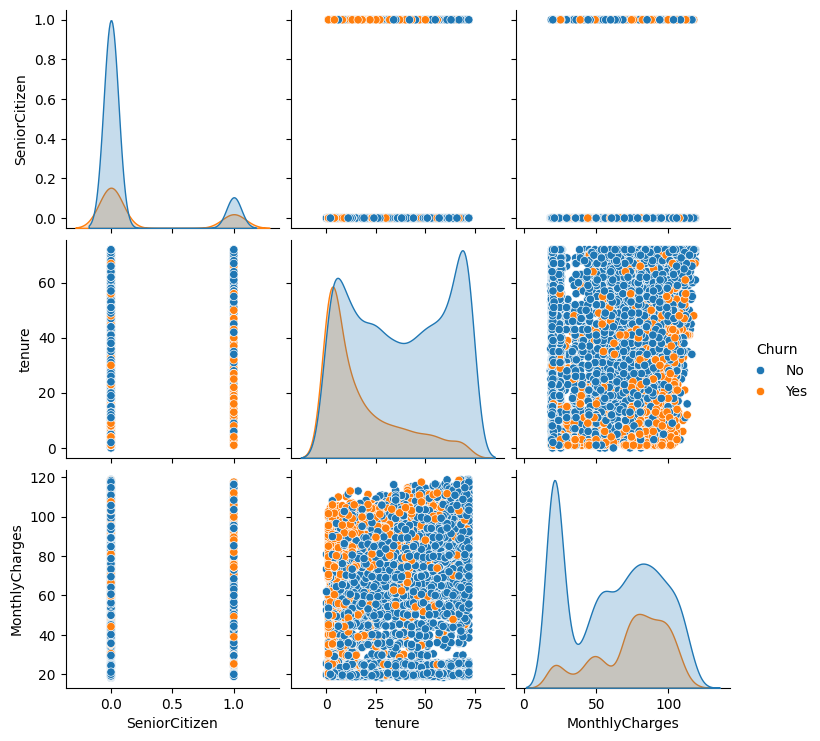

In [13]:
sns.pairplot(df,hue="Churn")
plt.show()

# Feature Engineering

In [14]:
# Drop useless column
df.drop("customerID", axis=1, inplace=True)

Encode the Target column(**Churn**) **Yes--> 1**  ,**No--> 0**

In [15]:
df['Churn'] = df['Churn'].map({'Yes':1 , 'No':0})

In [16]:
df['Churn'].isnull().sum()

np.int64(0)

In [17]:
print(df["TotalCharges"].unique())

['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']


Total Charges column contains int values in string (quotes) such as '29.85'

In [18]:
# Remove quotes from int values.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [19]:
df['TotalCharges'].dtypes

dtype('float64')

In [20]:
df['TotalCharges'].isnull().sum()

np.int64(11)

After removing quotes df['TotalCharges'] contains null /NaN values.

In [21]:
# Fill the null values ,using fillna.
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [22]:
df['TotalCharges'].isnull().sum()

np.int64(0)

No null values founded.

Define **X** as Features and **y** as Target. 

In [23]:
X = df.drop('Churn',axis=1)
y = df['Churn']

# train_test_split the data

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train.shape,X_test.shape

((5634, 19), (1409, 19))

Our dataset distributed for training -->**80%** , for testing -->**20%.**

# Preprocessing the data

In [27]:
# Separate the categorical values and Numerical values.
categorical = X.select_dtypes(include=["object"]).columns
numerical = X.select_dtypes(include=["int64","float64"]).columns

In [28]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [29]:
# Using Column transformer
preprocess = ColumnTransformer(
    transformers=[
        ("cat" , OneHotEncoder(handle_unknown="ignore"),categorical),
        ("num" , StandardScaler(),numerical)
    ]
)

In [30]:
X_train_preprocess = preprocess.fit_transform(X_train)
X_test_preprocess = preprocess.transform(X_test)

In [31]:
X_train_preprocess

array([[ 1.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
        -4.65683364e-01, -4.73723375e-04, -4.21345130e-01],
       [ 1.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
         8.85536787e-01,  1.07475386e+00,  1.25588791e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00, ...,
        -1.28460467e+00, -1.37649913e+00, -1.00215117e+00],
       ...,
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00, ...,
        -8.34197950e-01, -1.45294499e+00, -8.77176266e-01],
       [ 0.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
        -8.34197950e-01,  1.14953785e+00, -4.81776199e-01],
       [ 0.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
        -2.60953038e-01, -1.49781538e+00, -8.10288602e-01]],
      shape=(5634, 45))

# Balance the target column using SMOTE().

In [32]:
from imblearn.over_sampling import SMOTE

In [33]:
smote = SMOTE()

In [34]:
X_train_balance,y_train_balance = smote.fit_resample(X_train_preprocess,y_train)

In [35]:
y_train_balance.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

# Apply Model

**1. Logistic Regression**

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
lg_model = LogisticRegression()

In [38]:
lg_model.fit(X_train_balance,y_train_balance)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
y_pred_lg = lg_model.predict(X_test_preprocess)

In [40]:
y_pred_lg

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

**Evaluate the model --> LogisticRegression**

In [41]:
from sklearn.metrics import confusion_matrix ,classification_report , accuracy_score

In [42]:
acc_lg = accuracy_score(y_test,y_pred_lg)
print("Accuracy_Score :",acc_lg)

Accuracy_Score : 0.7544357700496807


In [43]:
# Confusion Matrix 
conf_max = confusion_matrix(y_test,y_pred_lg)
print("Confusion_matrix")
print(conf_max)

Confusion_matrix
[[757 279]
 [ 67 306]]


In [44]:
# Classification Report 
class_report = classification_report(y_test,y_pred_lg)
print('Classification_Report :')
print(class_report)

Classification_Report :
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1036
           1       0.52      0.82      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.75      0.77      1409



**2. Random Forest Classifier**

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf_model = RandomForestClassifier(n_estimators=400)

In [47]:
rf_model.fit(X_train_balance,y_train_balance)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
y_pred_rf = rf_model.predict(X_test_preprocess)

In [49]:
y_pred_rf

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

**Evaluate the model --> Random Forest Classifier**

In [50]:
# Cheaking Accuracy of this model
acc_rf = accuracy_score(y_test,y_pred_rf)
print("Accuracy Score :",acc_rf)

Accuracy Score : 0.7842441447835344


In [51]:
con_max_rf = confusion_matrix(y_test,y_pred_rf)
print("Confusion Matrix :")
print(con_max_rf)

Confusion Matrix :
[[897 139]
 [165 208]]


In [52]:
class_rep_rf = classification_report(y_test,y_pred_rf)
print("Classification Report :")
print(class_rep_rf)

Classification Report :
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1036
           1       0.60      0.56      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



**3. XGBoost model.**

In [53]:
from xgboost import XGBClassifier

In [82]:
xgb = XGBClassifier(n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

In [83]:
xgb.fit(X_train_balance,y_train_balance)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [84]:
y_pred_xgb = xgb.predict(X_test_preprocess)

**Evaluate the model --> XGBClassifier**

In [85]:
#Cheaking accuracy score
accuracy_score(y_test,y_pred_xgb)

0.7984386089425124

In [86]:
# Confusion matrix
con_max_xgb = confusion_matrix(y_test,y_pred_xgb)
print("Confusion_matrix :")
print(con_max_xgb)

Confusion_matrix :
[[874 162]
 [122 251]]


In [87]:
# Classification Report :
class_rep_xgb = classification_report(y_test,y_pred_xgb)
print("Classification Report :")
print(class_rep_xgb)

Classification Report :
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1036
           1       0.61      0.67      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409



# Cheaking Overfitting 

In [88]:
y_train_score = xgb.predict(X_train_balance)
train_acc = accuracy_score(y_train_balance,y_train_score)

y_test_score = xgb.predict(X_test_preprocess)
test_acc = accuracy_score(y_test,y_test_score)


In [89]:
print("Training_accuracy :",train_acc)
print("Testing_accuracy :",test_acc)

Training_accuracy : 0.8637022716288062
Testing_accuracy : 0.7984386089425124


# Final Model Pipeline

In [62]:
from imblearn.pipeline import Pipeline

In [63]:
model_pipeline = Pipeline([
    ("process_data",preprocess),
    ("smote",smote),
    ("model",xgb)
])

In [64]:
model_pipeline.fit(X_train,y_train)

,steps,"[('process_data', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

# Save the model

In [65]:
import joblib

joblib.dump(model_pipeline, "churn_model.pkl")

['churn_model.pkl']

# Deployment (Streamlit App)

In [ ]:
import streamlit as st
import pandas as pd
import joblib

# Load trained pipeline model
model = joblib.load("churn_model.pkl")

st.title("Customer Churn Prediction")

st.write("Enter customer details")


gender = st.selectbox("Gender", ["Male", "Female"])

SeniorCitizen = st.selectbox("Senior Citizen", [0,1])

Partner = st.selectbox("Partner", ["Yes","No"])

Dependents = st.selectbox("Dependents", ["Yes","No"])

tenure = st.slider("Tenure (months)",0,72,12)

PhoneService = st.selectbox("Phone Service", ["Yes","No"])

MultipleLines = st.selectbox("Multiple Lines", ["No","Yes","No phone service"])

InternetService = st.selectbox("Internet Service", ["DSL","Fiber optic","No"])

OnlineSecurity = st.selectbox("Online Security", ["Yes","No","No internet service"])

OnlineBackup = st.selectbox("Online Backup", ["Yes","No","No internet service"])

DeviceProtection = st.selectbox("Device Protection", ["Yes","No","No internet service"])

TechSupport = st.selectbox("Tech Support", ["Yes","No","No internet service"])

StreamingTV = st.selectbox("Streaming TV", ["Yes","No","No internet service"])

StreamingMovies = st.selectbox("Streaming Movies", ["Yes","No","No internet service"])

Contract = st.selectbox("Contract", ["Month-to-month","One year","Two year"])

PaperlessBilling = st.selectbox("Paperless Billing", ["Yes","No"])

PaymentMethod = st.selectbox("Payment Method",
["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])

MonthlyCharges = st.number_input("Monthly Charges")

TotalCharges = st.number_input("Total Charges")



input_data = pd.DataFrame({

"gender":[gender],
"SeniorCitizen":[SeniorCitizen],
"Partner":[Partner],
"Dependents":[Dependents],
"tenure":[tenure],
"PhoneService":[PhoneService],
"MultipleLines":[MultipleLines],
"InternetService":[InternetService],
"OnlineSecurity":[OnlineSecurity],
"OnlineBackup":[OnlineBackup],
"DeviceProtection":[DeviceProtection],
"TechSupport":[TechSupport],
"StreamingTV":[StreamingTV],
"StreamingMovies":[StreamingMovies],
"Contract":[Contract],
"PaperlessBilling":[PaperlessBilling],
"PaymentMethod":[PaymentMethod],
"MonthlyCharges":[MonthlyCharges],
"TotalCharges":[TotalCharges]

})



if st.button("Predict"):

    prediction = model.predict(input_data)
    prob = model.predict_proba(input_data)

    if prediction[0] == 1:
        st.error("Yes! Customer will Churn")
    else:
        st.success("No! Customer will not churn")

    st.write("Churn Probability:",prob[0][1])